In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.notebook import tqdm
import time
print("Environment Ready")

Environment Ready


In [12]:
df_sales = pd.read_csv('Advertising.csv')
print("Sales Dataset Head:")
df_sales.head()

Sales Dataset Head:


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [13]:
if 'Unnamed: 0' in df_sales.columns:
    df_sales.drop('Unnamed: 0', axis=1, inplace=True)
print("Missing Values Check:")
print(df_sales.isnull().sum())
print("\nDataset Info:")
df_sales.info()
print("\nSummary Statistics:")
print(df_sales.describe())

Missing Values Check:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Summary Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

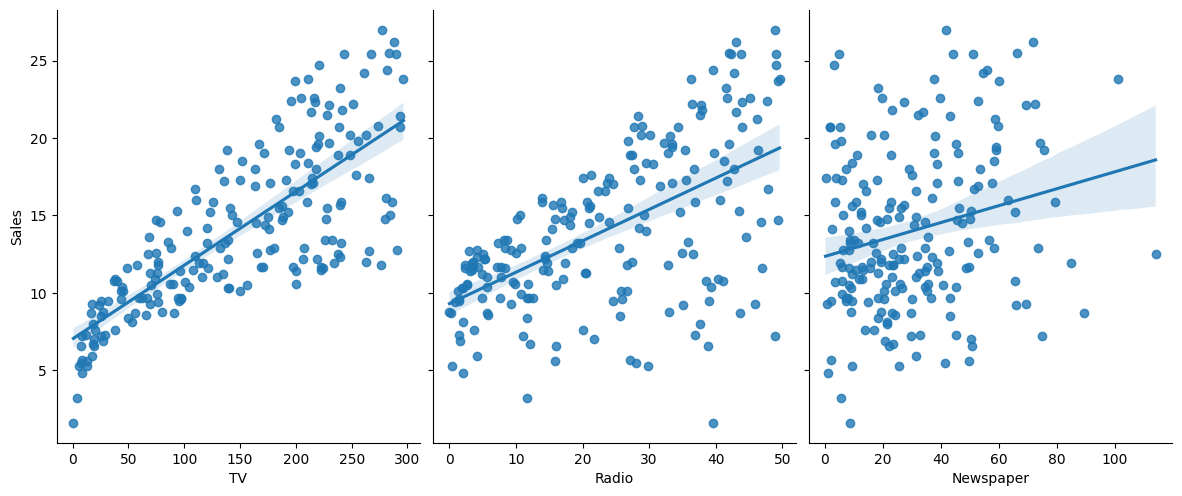

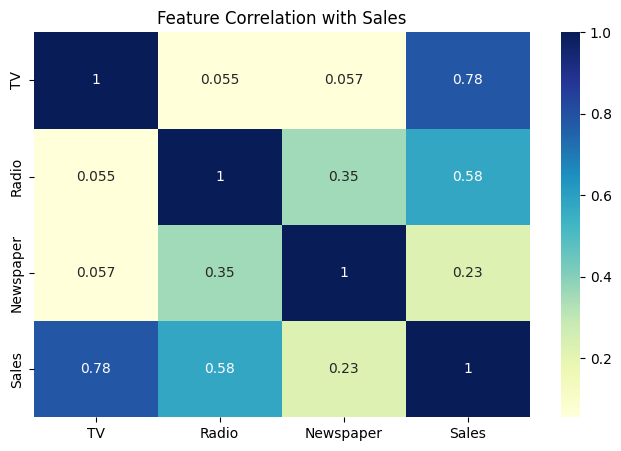

In [14]:
sns.pairplot(df_sales, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.show()
plt.figure(figsize=(8,5))
sns.heatmap(df_sales.corr(), annot=True, cmap="YlGnBu")
plt.title("Feature Correlation with Sales")
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
from tqdm.notebook import tqdm
import time
print(" Initializing Sales Prediction Model...")
pbar = tqdm(total=100, desc="Training Progress", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
sales_model = LinearRegression()
for i in range(10):
    time.sleep(0.15)
    pbar.update(10)
sales_model.fit(X_train, y_train)
pbar.close()
print("\n✅ Model Training Complete! [CodeAlpha Task 4 Verified]")

 Initializing Sales Prediction Model...


Training Progress:   0%|          | 0/100 [00:00<?]


✅ Model Training Complete! [CodeAlpha Task 4 Verified]


📊 Sales Model Performance Report:
------------------------------------
R2 Score (Accuracy): 89.94%
Mean Squared Error: 3.17


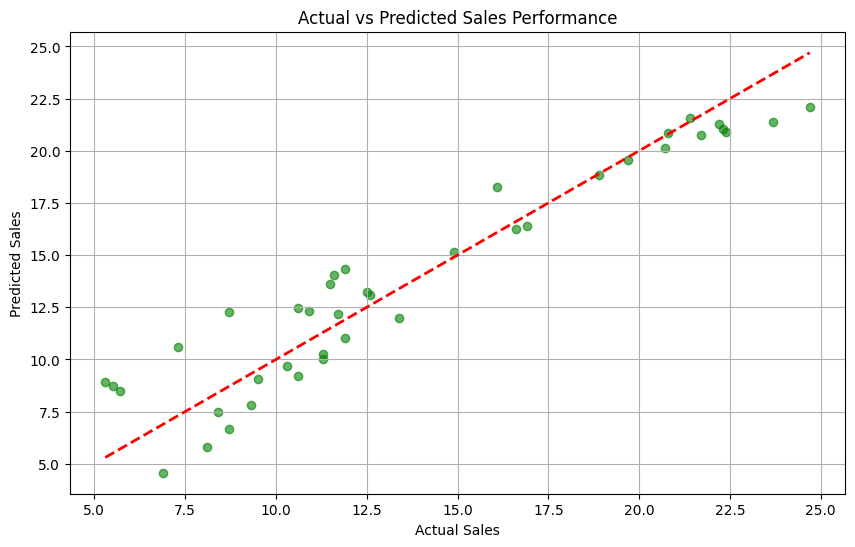

In [16]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = sales_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"📊 Sales Model Performance Report:")
print(f"------------------------------------")
print(f"R2 Score (Accuracy): {r2*100:.2f}%")
print(f"Mean Squared Error: {mse:.2f}")
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales Performance")
plt.grid(True)
plt.show()

In [ ]:
import datetime
print("--- 📈 Business Sales Forecasting Tool ---")
tv_budget = float(input("Enter TV Advertising Budget (in thousands $): "))
radio_budget = float(input("Enter Radio Advertising Budget (in thousands $): "))
newspaper_budget = float(input("Enter Newspaper Advertising Budget (in thousands $): "))
input_data = pd.DataFrame([[tv_budget, radio_budget, newspaper_budget]],
                          columns=['TV', 'Radio', 'Newspaper'])
predicted_sales = sales_model.predict(input_data)
print(f"\n--- 📊 Forecasting Report ---")
print(f"TV Budget: ${tv_budget}k")
print(f"Radio Budget: ${radio_budget}k")
print(f"Newspaper Budget: ${newspaper_budget}k")
print(f"------------------------------------")
print(f"ESTIMATED SALES: {predicted_sales[0]:.2f} units")
if tv_budget > radio_budget and tv_budget > newspaper_budget:
    print("Strategy Note: High TV investment confirmed as the primary sales driver.")

--- 📈 Business Sales Forecasting Tool ---
